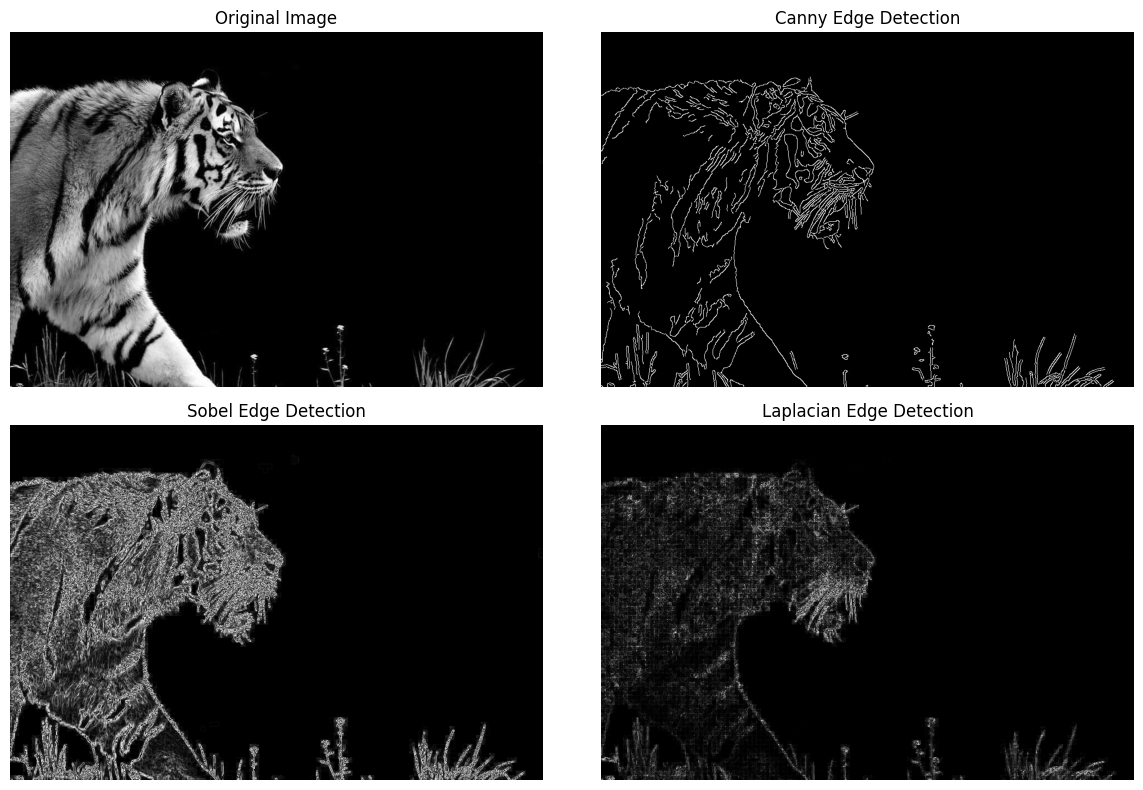

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found!")
    exit()

blurred = cv2.GaussianBlur(image, (5,5), 1.4)

canny_edges = cv2.Canny(blurred, threshold1=100, threshold2=200)

sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

sobel_edges = cv2.magnitude(sobelx, sobely)
sobel_edges = np.uint8(np.absolute(sobel_edges))

laplacian_edges = cv2.Laplacian(image, cv2.CV_64F)
laplacian_edges = np.uint8(np.absolute(laplacian_edges))

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(canny_edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(sobel_edges, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(laplacian_edges, cmap='gray')
plt.title("Laplacian Edge Detection")
plt.axis('off')

plt.tight_layout()
plt.show()